In [1]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q=0.85)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

In [2]:
df_countries.loc[
    df_countries["fossil_fuel_energy_consumption_of_total"] < 0,
    "fossil_fuel_energy_consumption_of_total"
] = np.nan

df_countries.loc[
    df_countries["gross_capital_formation_of_gdp"] < 0,
    "gross_capital_formation_of_gdp"
] = np.nan

df_countries.drop(columns=['exports_of_goods_and_services_of_gdp', 'imports_of_goods_and_services_of_gdp'], inplace=True)

############################################################

df_countries['trade_of_gdp_log'] = np.log1p(df_countries['trade_of_gdp'])
df_countries.drop(columns=['trade_of_gdp'], inplace=True)


index_components = [
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
]

internet_col = "individuals_using_the_internet_of_population"

# 1. Country-level mean
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("country_code")[internet_col]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("year")[internet_col]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(df_countries[internet_col].mean())
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_countries[
    [f"{col}_z" for col in index_components]
] = scaler.fit_transform(
    df_countries[index_components]
)

df_countries["Socioeconomic_developmen_Index"] = (
    df_countries[[f"{col}_z" for col in index_components]]
    .mean(axis=1)
)

df_countries.drop(columns=[
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population",
    'individuals_using_the_internet_of_population_z',
    'life_expectancy_at_birth_total_years_z',
    'urban_population_of_total_population_z',
    'access_to_electricity_of_population_z'
], inplace=True)

############################################################

energy_cols = [
    "energy_use_kg_of_oil_equivalent_per_capita",
    "carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita"
]


# 1. Country-level mean
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("country_code")[energy_cols]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("year")[energy_cols]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(df_countries[energy_cols].mean())
)


# 4. LOG TRANSFORMATION

df_log = np.log1p(df_countries[energy_cols])


# 5. STANDARDIZATION
scaler = StandardScaler()
z_cols = [f"{col}_z" for col in energy_cols]
df_countries[z_cols] = scaler.fit_transform(df_log)


# 6. CREATE ENERGY & ENVIRONMENTAL INDEX
df_countries["Energy_Environmental_Index"] = (
    df_countries[z_cols].mean(axis=1)
)


# 7. DROP ORIGINAL COMPONENTS
df_countries.drop(columns=energy_cols, inplace=True)
df_countries.drop(columns=['energy_use_kg_of_oil_equivalent_per_capita_z', 'carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita_z'], inplace=True)

############################################################

df_countries['domestic_credit_to_private_sector_of_gdp_log'] = np.log1p(df_countries['domestic_credit_to_private_sector_of_gdp'])
df_countries.drop(columns= 'domestic_credit_to_private_sector_of_gdp', inplace=True)

############################################################

fdi = df_countries['foreign_direct_investment_net_inflows_of_gdp']

df_countries['fdi_log'] = np.sign(fdi) * np.log1p(np.abs(fdi))
df_countries.drop(columns='foreign_direct_investment_net_inflows_of_gdp', inplace=True)

############################################################

inflation = df_countries['inflation_consumer_prices_annual_']

df_countries['inflation_log'] = (np.sign(inflation)* np.log1p(np.abs(inflation)))
df_countries.drop(columns='inflation_consumer_prices_annual_', inplace=True)

############################################################

df_countries['broad_money_of_gdp_log'] = np.log1p(df_countries['broad_money_of_gdp'])
df_countries.drop(columns='broad_money_of_gdp', inplace=True)

############################################################

df_countries['gdp_per_capita_constant_2015_us_log'] = np.log1p(df_countries['gdp_per_capita_constant_2015_us'])
df_countries.drop(columns='gdp_per_capita_constant_2015_us', inplace=True)

############################################################

df_countries['military_expenditure_of_general_government_expenditure_log'] = np.log1p(df_countries['military_expenditure_of_general_government_expenditure'])
df_countries.drop(columns='military_expenditure_of_general_government_expenditure', inplace=True)

In [3]:
low_missing_cols = [
    'agriculture_forestry_and_fishing_value_added_of_gdp',
    'carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp',
    'current_health_expenditure_of_gdp',
    'forest_area_of_land_area',
    'gdp_growth_annual_',
    'industry_including_construction_value_added_of_gdp',
    'renewable_electricity_output_of_total_electricity_output',
    'school_enrollment_primary_gross',
    'services_value_added_of_gdp',
    'unemployment_total_of_total_labor_force_modeled_ilo_estimate',
    'domestic_credit_to_private_sector_of_gdp_log',
    'fdi_log',
    'inflation_log',
    'gdp_per_capita_constant_2015_us_log',
    'renewable_energy_consumption_of_total_final_energy_consumption'
]

df_countries = (
    df_countries
    .sort_values(["country_code", "year"])
    .reset_index(drop=True)
)


for col in low_missing_cols:

    # ==================================================
    # 1. Interpolate small internal gaps within country
    # ==================================================

    df_countries[col] = (
        df_countries
        .groupby("country_code")[col]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit=3,
                limit_area="inside"
            )
        )
    )

    # ==================================================
    # 2. Calculate each country's typical value
    # ==================================================

    country_medians = (
        df_countries
        .groupby("country_code")[col]
        .median()
    )

    # ==================================================
    # 3. Assign countries to deciles
    # ==================================================

    country_groups = pd.qcut(
        country_medians.rank(method="first"),
        q=10,
        labels=[f"Decile_{i}" for i in range(1, 11)]
    )

    # ==================================================
    # 4. Calculate median of country medians
    #    within each decile
    # ==================================================

    decile_medians = (
        country_medians
        .groupby(country_groups, observed=True)
        .median()
    )

    # ==================================================
    # 5. Map each country's decile to its rows
    # ==================================================

    row_groups = df_countries["country_code"].map(country_groups)

    # ==================================================
    # 6. Impute using country's decile median
    # ==================================================

    decile_imputation = row_groups.map(decile_medians)

    df_countries[col] = (
        df_countries[col]
        .fillna(decile_imputation)
    )

    # ==================================================
    # 7. If country has no historical data → year median
    # ==================================================

    df_countries[col] = (
        df_countries[col]
        .fillna(
            df_countries
            .groupby("year")[col]
            .transform("median")
        )
    )

    # ==================================================
    # 8. Absolute final fallback → global median
    # ==================================================

    df_countries[col] = (
        df_countries[col]
        .fillna(df_countries[col].median())
    )

############################################################

# ==============================================================================
# HIGH-MISSING INDICATORS
# ==============================================================================

high_missing_cols = [
    "fossil_fuel_energy_consumption_of_total",
    "military_expenditure_of_general_government_expenditure_log",
    "broad_money_of_gdp_log",
    "gross_capital_formation_of_gdp",
    "trade_of_gdp_log",
]

anchor_col = "gdp_per_capita_constant_2015_us_log"


# ==============================================================================
# 1. CREATE IMPUTATION METHOD COLUMNS
# ==============================================================================

imputation_method_cols = {}

for col in high_missing_cols:

    method_col = f"{col}_imputation_method"

    imputation_method_cols[col] = method_col

    df_countries[method_col] = np.where(
        df_countries[col].isna(),
        "missing",
        "observed"
    )


# ==============================================================================
# 2. STRUCTURAL ZERO
# ==============================================================================

no_military_countries = [
    "CRI",
    "ISL",
    "KIR",
    "FSM",
    "MUS",
    "PAN"
]

military_col = "military_expenditure_of_general_government_expenditure_log"

mask_structural_zero = (
    df_countries["country_code"].isin(no_military_countries)
    & df_countries[military_col].isna()
)

df_countries.loc[
    mask_structural_zero,
    military_col
] = 0.0

df_countries.loc[
    mask_structural_zero,
    imputation_method_cols[military_col]
] = "structural_zero"


# ==============================================================================
# 3. PREPARE GDP-PER-CAPITA ANCHOR
# ==============================================================================

clean_anchor_series = (
    df_countries
    .groupby("country_code")[anchor_col]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit=3,
            limit_area="inside"
        )
    )
)

country_anchor_medians = (
    clean_anchor_series
    .groupby(df_countries["country_code"])
    .transform("median")
)

global_anchor_median = clean_anchor_series.median()

clean_anchor_series = (
    clean_anchor_series
    .fillna(country_anchor_medians)
    .fillna(global_anchor_median)
)

country_anchor_ranks = (
    clean_anchor_series
    .groupby(df_countries["country_code"])
    .median()
)


# ==============================================================================
# 4. IMPUTE HIGH-MISSING INDICATORS
# ==============================================================================

for col in high_missing_cols:

    method_col = imputation_method_cols[col]

    # --------------------------------------------------------------------------
    # Save ORIGINAL fallback statistics
    # --------------------------------------------------------------------------

    raw_global_median = df_countries[col].median()

    raw_year_medians = (
        df_countries
        .groupby("year")[col]
        .transform("median")
    )

    # --------------------------------------------------------------------------
    # STEP A — LINEAR INTERPOLATION
    # --------------------------------------------------------------------------

    before = df_countries[col].isna()

    df_countries[col] = (
        df_countries
        .groupby("country_code")[col]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit=3,
                limit_area="inside"
            )
        )
    )

    mask = before & df_countries[col].notna()

    df_countries.loc[
        mask,
        method_col
    ] = "interpolation"


    # --------------------------------------------------------------------------
    # STEP B — COUNTRY MEDIANS
    # --------------------------------------------------------------------------

    country_medians = (
        df_countries
        .groupby("country_code")[col]
        .median()
    )


    # --------------------------------------------------------------------------
    # STEP C — COUNTRY RANKING
    #
    # If the country has data for this indicator:
    #     rank using its own median
    #
    # If the country has NO data:
    #     rank using GDP-per-capita anchor
    # --------------------------------------------------------------------------

    ranking_series = (
        country_medians
        .fillna(country_anchor_ranks)
    )


    # --------------------------------------------------------------------------
    # STEP D — CREATE DECILES
    # --------------------------------------------------------------------------

    valid_ranking = ranking_series.dropna()

    n_quantiles = min(
        10,
        len(valid_ranking)
    )

    if n_quantiles >= 2:

        country_groups = pd.qcut(
            ranking_series.rank(method="first"),
            q=n_quantiles,
            labels=[
                f"Decile_{i}"
                for i in range(1, n_quantiles + 1)
            ],
            duplicates="drop"
        )

    else:

        country_groups = pd.Series(
            index=ranking_series.index,
            dtype="object"
        )


    # --------------------------------------------------------------------------
    # STEP E — MAP COUNTRY → DECILE
    # --------------------------------------------------------------------------

    row_groups = df_countries["country_code"].map(
        country_groups
    )


    # --------------------------------------------------------------------------
    # STEP F — CALCULATE DECILE MEDIANS
    # --------------------------------------------------------------------------

    decile_medians = (
        df_countries
        .groupby(
            row_groups,
            observed=True
        )[col]
        .median()
    )

    decile_imputation = row_groups.map(
        decile_medians
    )


    # --------------------------------------------------------------------------
    # STEP G — DECILE MEDIAN IMPUTATION
    # --------------------------------------------------------------------------

    before = df_countries[col].isna()

    df_countries[col] = (
        df_countries[col]
        .fillna(decile_imputation)
    )

    mask = before & df_countries[col].notna()

    df_countries.loc[
        mask,
        method_col
    ] = "decile_median"


    # --------------------------------------------------------------------------
    # STEP H — YEARLY CROSS-SECTIONAL MEDIAN
    # --------------------------------------------------------------------------

    before = df_countries[col].isna()

    df_countries[col] = (
        df_countries[col]
        .fillna(raw_year_medians)
    )

    mask = before & df_countries[col].notna()

    df_countries.loc[
        mask,
        method_col
    ] = "yearly_median"


    # --------------------------------------------------------------------------
    # STEP I — GLOBAL MEDIAN
    # --------------------------------------------------------------------------

    before = df_countries[col].isna()

    df_countries[col] = (
        df_countries[col]
        .fillna(raw_global_median)
    )

    mask = before & df_countries[col].notna()

    df_countries.loc[
        mask,
        method_col
    ] = "global_median"

### **Now ready to start the model**

In [4]:
df_countries = df_countries.drop(columns=['fossil_fuel_energy_consumption_of_total', 'gross_capital_formation_of_gdp', 'school_enrollment_primary_gross', 'trade_of_gdp_log', 'domestic_credit_to_private_sector_of_gdp_log', 'broad_money_of_gdp_log', 'military_expenditure_of_general_government_expenditure_log'])

In [5]:
df_countries.head()

Series Name,country_name,country_code,year,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,gdp_growth_annual_,industry_including_construction_value_added_of_gdp,...,Socioeconomic_developmen_Index,Energy_Environmental_Index,fdi_log,inflation_log,gdp_per_capita_constant_2015_us_log,fossil_fuel_energy_consumption_of_total_imputation_method,military_expenditure_of_general_government_expenditure_log_imputation_method,broad_money_of_gdp_log_imputation_method,gross_capital_formation_of_gdp_imputation_method,trade_of_gdp_log_imputation_method
0,Aruba,ABW,2010,0.020492,0.186434,5.466372,1.855,2.333333,-2.733457,11.546062,...,0.365550,0.482338,2.153119,1.124326,10.143693,decile_median,yearly_median,observed,observed,observed
1,Aruba,ABW,2011,0.020395,0.108595,5.615796,1.858,2.333333,3.369237,12.366448,...,0.491734,0.247824,2.970711,1.670777,10.169463,decile_median,yearly_median,observed,observed,observed
2,Aruba,ABW,2012,0.021469,0.141711,5.636585,1.907,2.333333,-1.040800,10.076063,...,0.539978,0.355452,-2.567498,0.487028,10.144303,decile_median,yearly_median,observed,observed,observed
3,Aruba,ABW,2013,0.017817,0.146413,5.718966,1.944,2.333333,6.431461,10.749665,...,0.586244,0.387884,2.395570,-1.215525,10.191712,decile_median,yearly_median,observed,observed,observed
4,Aruba,ABW,2014,0.014813,0.154251,5.837747,1.944,2.333333,1.426100,10.799498,...,0.630902,0.402172,2.135970,0.351671,10.195217,decile_median,yearly_median,observed,observed,observed


In [6]:
features = df_countries.iloc[:, 3:-5].columns.to_list()

# df_countries = (
#     df_countries
#     .groupby("country_code")[features]
#     .mean()
#     .reset_index()
# )

X = df_countries[features]

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

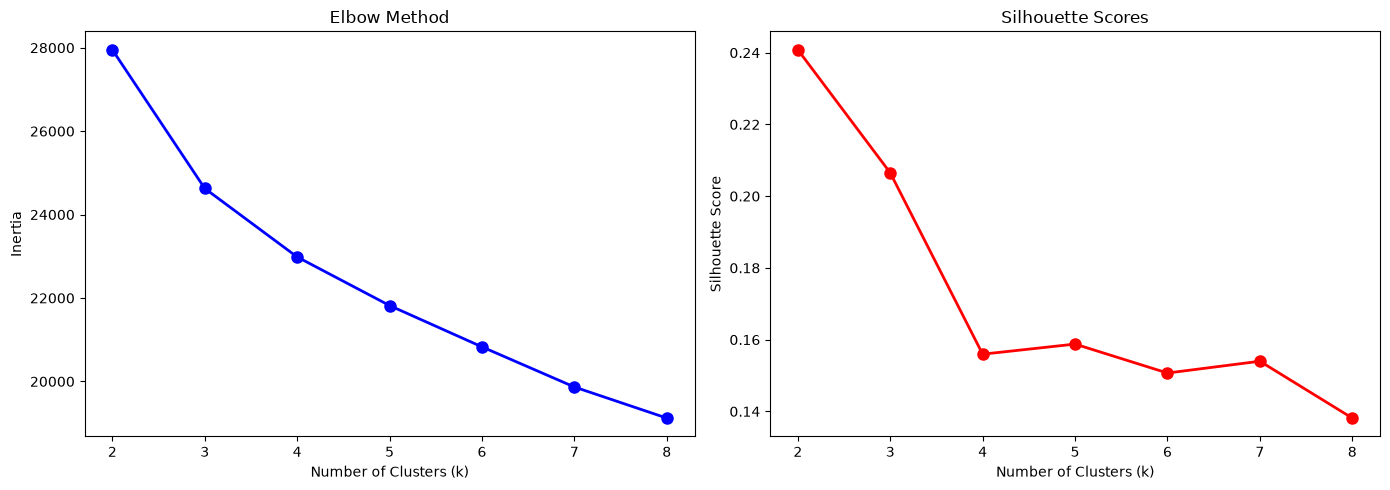

k = 2 | Silhouette Score = 0.2408
k = 3 | Silhouette Score = 0.2065
k = 4 | Silhouette Score = 0.1559
k = 5 | Silhouette Score = 0.1588
k = 6 | Silhouette Score = 0.1507
k = 7 | Silhouette Score = 0.1540
k = 8 | Silhouette Score = 0.1381


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 9)

# 1. Loop through possible cluster counts
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 2. Plot Elbow Method & Silhouette Scores side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax[0].plot(K_range, inertia, "bo-", linewidth=2, markersize=8)
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")

# Silhouette Curve
ax[1].plot(K_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Scores")

plt.tight_layout()
plt.show()

# Print Silhouette Scores directly
for k, score in zip(K_range, silhouette_scores):
    print(f"k = {k} | Silhouette Score = {score:.4f}")

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features: {X_pca.shape[1]}")

# View the variance explained by each individual component
print(f"Variance explained per component: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

Original number of features: 17
Reduced number of features: 2
Variance explained per component: [0.33129299 0.13604139]
Total variance explained: 46.73%


In [10]:
Kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_countries["Cluster"] = Kmeans.fit_predict(X_pca)

In [11]:
df_countries['Cluster'].value_counts()

Cluster
1    714
3    502
2    452
4    268
0    248
Name: count, dtype: int64

In [12]:
cluster_summary = df_countries.groupby('Cluster')[features].mean().reset_index()
cluster_summary

Series Name,Cluster,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,gdp_growth_annual_,industry_including_construction_value_added_of_gdp,population_growth_annual_,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,services_value_added_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,Socioeconomic_developmen_Index,Energy_Environmental_Index,fdi_log,inflation_log,gdp_per_capita_constant_2015_us_log
0,0,14.060596,0.732426,3.971219,3.281476,36.176158,3.673162,34.599326,1.951577,30.507255,31.746371,43.698433,7.878895,-0.377819,-0.574126,1.098844,1.821094,7.777473
1,1,2.771240,0.315918,8.262972,1.631957,32.956138,1.804573,20.639014,0.436764,31.043320,18.616106,66.399027,9.098450,0.776989,0.653679,1.454656,0.864820,10.012152
2,2,25.191014,0.299666,5.151699,4.745146,31.830445,4.308853,22.523962,2.529830,52.595455,73.050664,46.230056,4.846863,-1.267975,-1.053644,1.159599,1.729820,6.818096
3,3,10.229867,0.396709,6.767044,2.608100,36.779128,2.863449,23.712230,1.032560,42.760654,29.301594,57.657576,9.441558,-0.042034,-0.313201,1.336837,1.378398,8.349531
4,4,4.869170,1.131682,4.643797,2.190149,18.036105,2.890996,43.986252,1.627041,5.481038,2.845149,48.137324,6.540944,0.496846,1.153473,0.957806,1.453581,9.253187


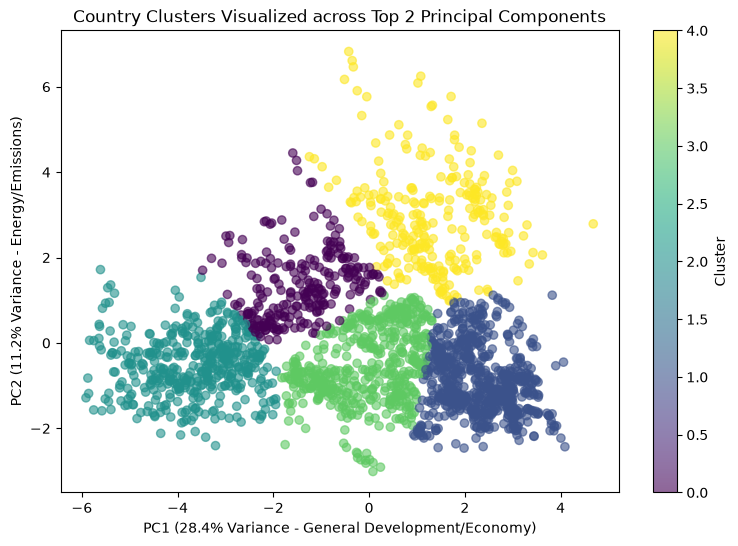

In [13]:
# Create a 2D plot using the top 2 principal components
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_countries["Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.xlabel("PC1 (28.4% Variance - General Development/Economy)")
plt.ylabel("PC2 (11.2% Variance - Energy/Emissions)")
plt.title("Country Clusters Visualized across Top 2 Principal Components")
plt.colorbar(label="Cluster")
plt.show()

In [14]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# Calculate quantitative metrics
sil = silhouette_score(X_pca, df_countries["Cluster"])
db = davies_bouldin_score(X_pca, df_countries["Cluster"])
ch = calinski_harabasz_score(X_pca, df_countries["Cluster"])

print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Index: {db:.3f}")
print(f"Calinski-Harabasz Index: {ch:.3f}")

Silhouette Score: 0.422
Davies-Bouldin Index: 0.831
Calinski-Harabasz Index: 2605.214


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

for n_components in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    kmeans = KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    print(
        f"PCA={n_components} | "
        f"Features={X_pca.shape[1]} | "
        f"Variance={pca.explained_variance_ratio_.sum():.2%} | "
        f"Silhouette={silhouette_score(X_pca, labels):.3f} | "
        f"DB={davies_bouldin_score(X_pca, labels):.3f} | "
        f"CH={calinski_harabasz_score(X_pca, labels):.1f}"
    )

PCA=0.1 | Features=1 | Variance=33.13% | Silhouette=0.552 | DB=0.530 | CH=11051.3
PCA=0.2 | Features=1 | Variance=33.13% | Silhouette=0.552 | DB=0.530 | CH=11051.3
PCA=0.3 | Features=1 | Variance=33.13% | Silhouette=0.552 | DB=0.530 | CH=11051.3
PCA=0.4 | Features=2 | Variance=46.73% | Silhouette=0.422 | DB=0.831 | CH=2605.2
PCA=0.5 | Features=3 | Variance=54.79% | Silhouette=0.346 | DB=1.081 | CH=1445.2
PCA=0.6 | Features=4 | Variance=62.32% | Silhouette=0.281 | DB=1.273 | CH=982.7
PCA=0.7 | Features=6 | Variance=74.73% | Silhouette=0.221 | DB=1.518 | CH=648.1
PCA=0.8 | Features=7 | Variance=80.13% | Silhouette=0.209 | DB=1.622 | CH=563.6
PCA=0.9 | Features=10 | Variance=91.94% | Silhouette=0.171 | DB=1.827 | CH=436.1


In [16]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save PCA
joblib.dump(pca, "pca.pkl")

# Save trained KMeans
joblib.dump(Kmeans, "kmeans.pkl")

# Save features
joblib.dump(features, "features.pkl")

['features.pkl']